# Exploratory Data Analysis (EDA)

### Objective

##### The goal is to understand and explore the behaviour of electivity consumers,indetify consumption pattern between flagged and normal conssumers. To make the further feature engineering and ML deployment easier.

In [1]:
import pandas as pd
import numpy as np 
from pathlib import Path
data_path=Path(r'C:\Users\vinee\ML_Project\data\raw\electricity_consumption_raw.csv')
df=pd.read_csv(data_path)
meta_col=['CONS_NO','FLAG']
con_data=df[ [col for col in df.columns if col not in meta_col]]

### Consumer level feature table

##### Instead of analysis millions of reading,we summarize each consumer.This consumer level dataset will be use further. 

In [2]:
#consumption=cons
consumer_feature=pd.DataFrame({
'CONS_NO':df['CONS_NO'],
'FLAG':df['FLAG'],
"mean_cons":con_data.mean(axis=1),
'median_cons':con_data.median(axis=1),
'std_cons':con_data.std(axis=1),
'min_cons':con_data.min(axis=1),
'max_cons':con_data.max(axis=1),
'total_cons':con_data.sum(axis=1),
'zero_days':(con_data==0).sum(axis=1),
'missing_days':con_data.isnull().sum(axis=1)
})
print(consumer_feature.shape)
consumer_feature.head(3)

(42372, 10)


,CONS_NO,FLAG,mean_cons,median_cons,std_cons,min_cons,max_cons,total_cons,zero_days,missing_days
0,0387DD8A07E07FDA6271170F86AD9151,1,0.947796,0.000,3.101514,0.0,18.29,976.23,862,4
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,4.606312,0.955,7.107997,0.0,44.57,3896.94,50,188
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,8.312549,5.070,10.289867,0.0,79.71,5935.16,34,320


### bussiness question 1
#### Do flagges consumer consume more electricity than normal?


In [3]:
consumer_feature.groupby('FLAG')['mean_cons'].describe()

,count,mean,std,min,25%,50%,75%,max
FLAG,,,,,,,,
0,38755.0,7.949317,19.726390,0.0,1.773992,5.465084,9.845143,1480.333181
1,3612.0,31.348244,272.550428,0.0,4.486381,8.804711,16.539695,13601.100000


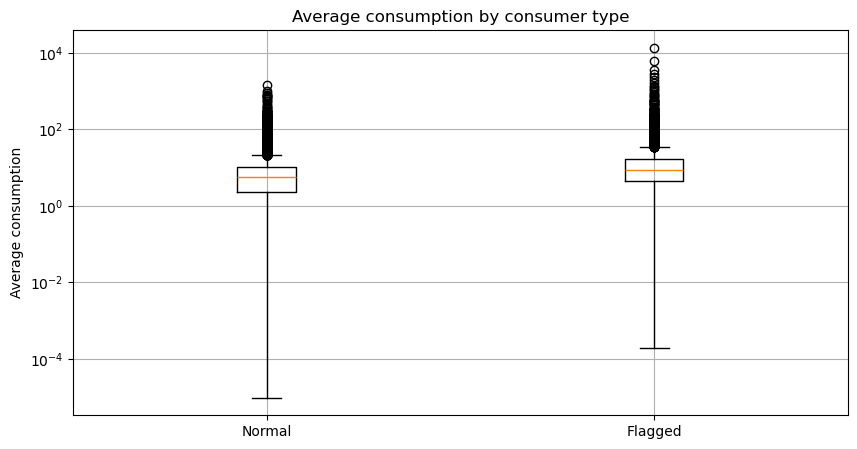

In [4]:
plot_data=consumer_feature.copy()
plot_data=plot_data[plot_data['mean_cons']>0]
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.boxplot([
plot_data.loc[plot_data['FLAG']==0,'mean_cons'],
plot_data.loc[plot_data['FLAG']==1,'mean_cons']],
tick_labels=['Normal','Flagged']
)
plt.grid()
plt.yscale('log')
plt.ylabel('Average consumption')
plt.title("Average consumption by consumer type")
plt.show()

#### Observation and Bussiness interpretation
##### 1. flagged consumer use more electricity 
##### 2. they exhibit high variablity
##### 3. They have exceptionally high average consumption
 

### Bussiness Question 2
#### Do flagged consumers experience more zero-consumption days than normal?

In [5]:
consumer_feature.groupby('FLAG')['zero_days'].describe()

,count,mean,std,min,25%,50%,75%,max
FLAG,,,,,,,,
0,38757.0,141.340738,268.384361,0.0,0.0,6.0,131.0,1033.0
1,3615.0,85.936376,176.243660,0.0,0.0,3.0,72.0,1033.0


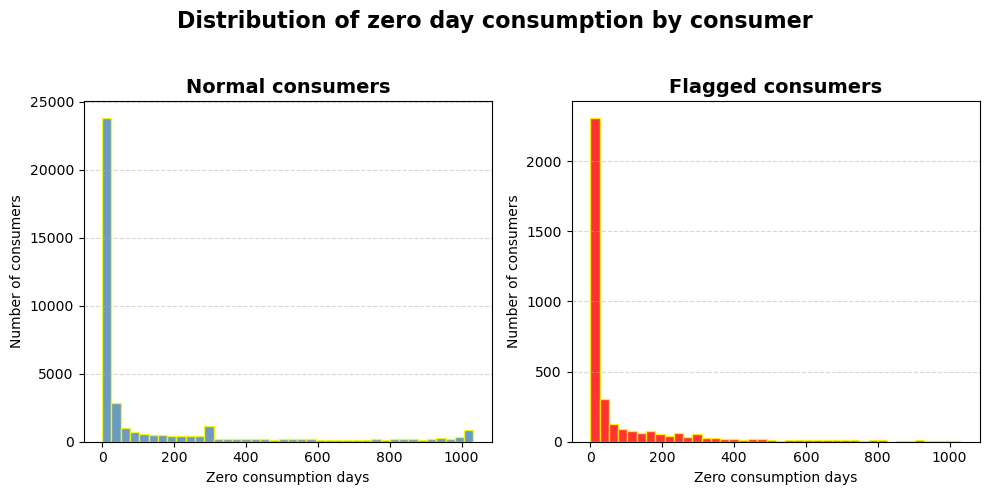

In [6]:
# Histogram
fig,ax=plt.subplots(1,2,figsize=(10,5))
# Normal Connsumer 
ax[0].hist(
consumer_feature.loc[consumer_feature['FLAG']==0,'zero_days'],
bins=40,alpha=0.8,label=['Normal'],color='steelblue',edgecolor='yellow'
)
ax[0].set_title("Normal consumers",fontsize=14,fontweight='bold')
ax[0].set_xlabel("Zero consumption days",fontsize=10)
ax[0].set_ylabel("Number of consumers",fontsize=10)
ax[0].grid(axis='y',linestyle='--',alpha=0.5)
# Flagged consumer
ax[1].hist(
consumer_feature.loc[consumer_feature['FLAG']==1,'zero_days'],
bins=40,alpha=0.8,label=['Normal'],color='red',edgecolor='yellow'
)
ax[1].set_title("Flagged consumers",fontsize=14,fontweight='bold')
ax[1].set_xlabel("Zero consumption days",fontsize=10)
ax[1].set_ylabel("Number of consumers",fontsize=10)
ax[1].grid(axis='y',linestyle='--',alpha=0.5)

fig.suptitle(
'Distribution of zero day consumption by consumer',
fontsize=16,fontweight='bold'
)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

#### Observation and bussiness interpretation
##### 1. zero-consumption days is highly right-skewed for both Normal and Flagged consumer.
##### 2. it is not a strong discriminator for identifying flagged consumers.

### Bussiness Question 3
#### Do flagged consumers exhibits high consumption variability?

In [7]:
consumer_feature.groupby('FLAG')['std_cons'].describe()

,count,mean,std,min,25%,50%,75%,max
FLAG,,,,,,,,
0,38755.0,8.027609,236.046972,0.0,1.362544,3.118178,5.424786,27954.247106
1,3612.0,29.520704,400.458242,0.0,3.241559,6.100638,10.949229,16228.642230


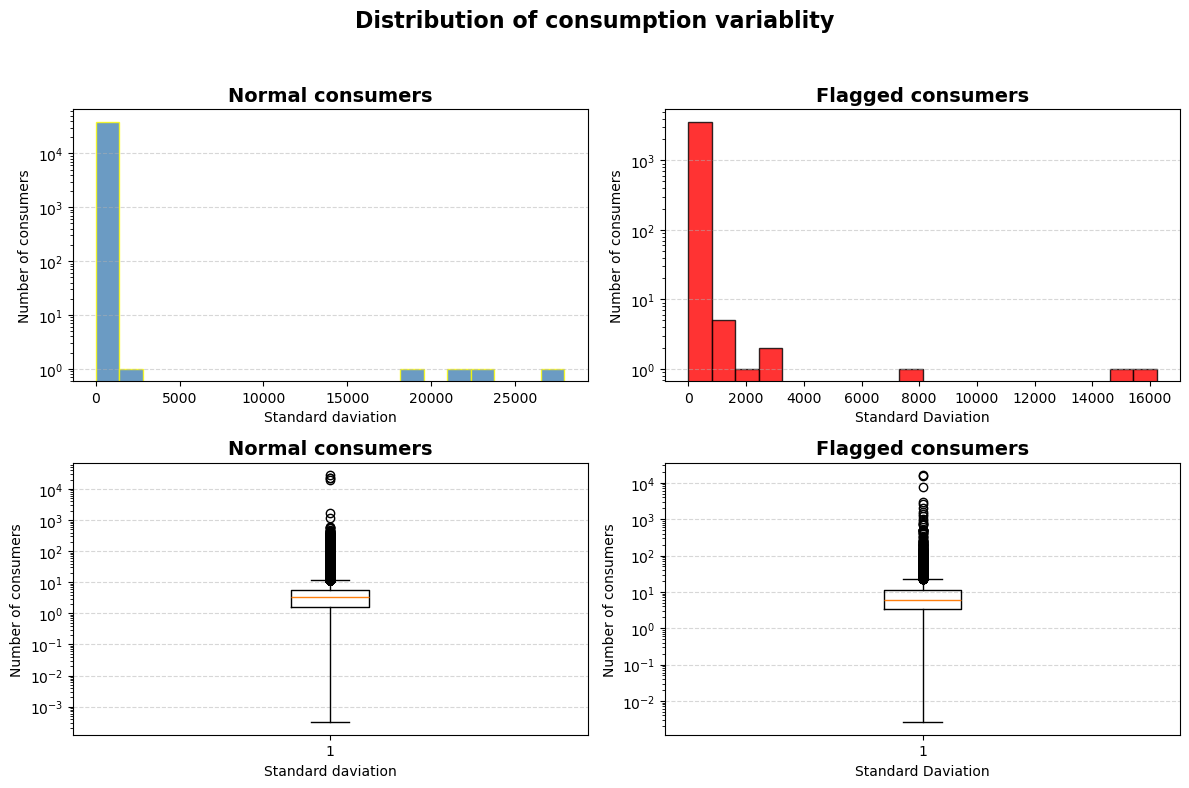

In [8]:
fig,ax=plt.subplots(2,2,figsize=(12,8))
# consumption variability
# Normal Consumer
ax[0,0].hist(
consumer_feature.loc[consumer_feature['FLAG']==0,'std_cons'],
bins=20,alpha=0.8,label=['Normal'],color='steelblue',edgecolor='yellow'
)
ax[0,0].set_title("Normal consumers",fontsize=14,fontweight='bold')
ax[0,0].set_xlabel("Standard daviation",fontsize=10)
ax[0,0].set_ylabel("Number of consumers",fontsize=10)
ax[0,0].set_yscale('log')
ax[0,0].grid(axis='y',linestyle='--',alpha=0.5)

# Flagged consumer
ax[0,1].hist(
consumer_feature.loc[consumer_feature['FLAG']==1,'std_cons'],
bins=20,alpha=0.8,label=['Normal'],color='red',edgecolor='black'
)
ax[0,1].set_title("Flagged consumers",fontsize=14,fontweight='bold')
ax[0,1].set_xlabel("Standard Daviation",fontsize=10)
ax[0,1].set_ylabel("Number of consumers",fontsize=10)
ax[0,1].grid(axis='y',linestyle='--',alpha=0.5)
ax[0,1].set_yscale('log')

# Boxplot 
ax[1,0].boxplot(
plot_data.loc[consumer_feature['FLAG']==0,'std_cons'],
label=['Normal']
)
ax[1,0].set_title("Normal consumers",fontsize=14,fontweight='bold')
ax[1,0].set_xlabel("Standard daviation",fontsize=10)
ax[1,0].set_ylabel("Number of consumers",fontsize=10)
ax[1,0].set_yscale('log')
ax[1,0].grid(axis='y',linestyle='--',alpha=0.5)

# Flagged consumer
ax[1,1].boxplot(
plot_data.loc[consumer_feature['FLAG']==1,'std_cons'],
label=['Normal']
)
ax[1,1].set_title("Flagged consumers",fontsize=14,fontweight='bold')
ax[1,1].set_xlabel("Standard Daviation",fontsize=10)
ax[1,1].set_ylabel("Number of consumers",fontsize=10)
ax[1,1].set_yscale('log')
ax[1,1].grid(axis='y',linestyle='--',alpha=0.5)

fig.suptitle(
'Distribution of consumption variablity',
fontsize=16,fontweight='bold'
)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

#### Observation
##### 1. standard deviation is highly right-skewed for both Normal and Flagged consumer
##### 2. the Flagged group shows a heavier upper tail and a greater number of high-variability outliers
##### 3. standard deviation appears to be a stronger discriminative feature than average consumption

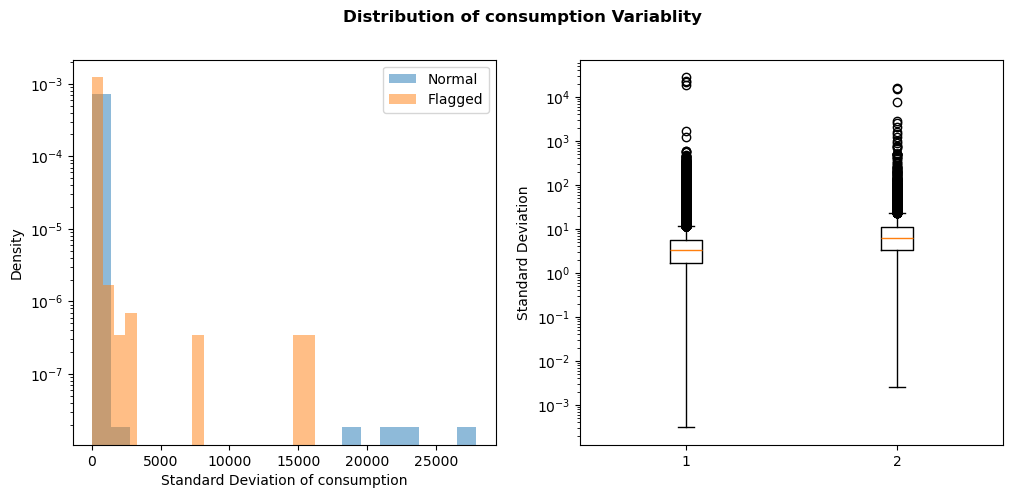

In [9]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
# normal consumer
ax[0].hist(
consumer_feature.loc[consumer_feature['FLAG']==0,'std_cons'],
bins=20,alpha=0.5,density=True,label='Normal'
)
# flagged consumer
ax[0].hist(
consumer_feature.loc[consumer_feature['FLAG']==1,'std_cons'],
bins=20,alpha=0.5,density=True,label='Flagged'
)
ax[0].set_xlabel('Standard Deviation of consumption',color='Black')
ax[0].set_ylabel('Density')
fig.suptitle("Distribution of consumption Variablity",color='Black',fontweight='bold')
ax[0].legend()
ax[0].set_yscale('log')

# boxplot (robust consumption)
# normal consumer
ax[1].boxplot([
plot_data.loc[plot_data['FLAG']==0,'std_cons'],
plot_data.loc[plot_data['FLAG']==1,'std_cons']])

ax[1].set_yscale('log')
ax[1].set_ylabel('Standard Deviation')

plt.show()

In [10]:
#mean comparison 
print(consumer_feature.groupby('FLAG')['std_cons'].mean())
#median comparison
print(consumer_feature.groupby('FLAG')['std_cons'].median())

FLAG
0     8.027609
1    29.520704
Name: std_cons, dtype: float64
FLAG
0    3.118178
1    6.100638
Name: std_cons, dtype: float64


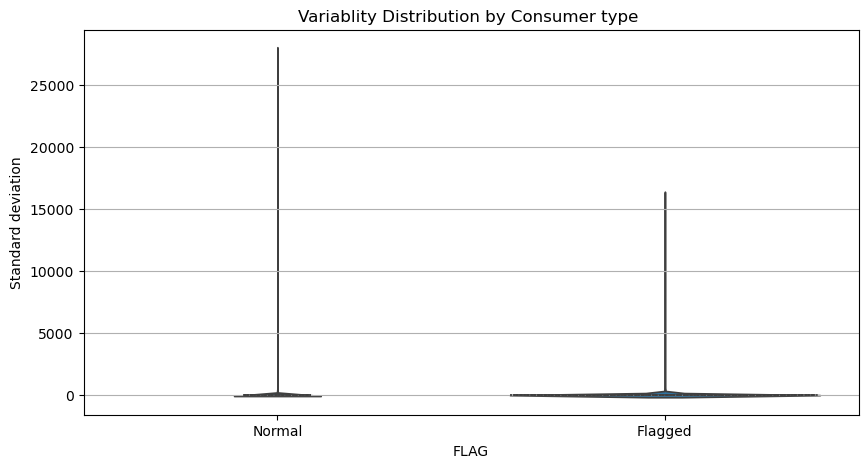

In [11]:
# violin visulization
import seaborn as sns
plt.figure(figsize=(10,5))
sns.violinplot(data=plot_data,x='FLAG',y='std_cons',inner='quartile')
plt.xticks([0,1],['Normal','Flagged'])
plt.ylabel('Standard deviation')
plt.title("Variablity Distribution by Consumer type ")
plt.grid(axis='y')
plt.show()

#### Observations and bussiness interpretation
##### 1.variability distributions of Normal and Flagged consumers exhibit substantial overlap
##### 2. Majority of consumer has low variability
##### 3. Extremely long upper tails
##### 4. Normal consumers have higher max variability
##### 5. Consumption variability alone cannot identify suspicious consumers

### Bussniness Question 4 
#### Do flagged consumer have higher total electrivity consumption ?


In [12]:
consumer_feature.groupby('FLAG')['total_cons'].describe()

,count,mean,std,min,25%,50%,75%,max
FLAG,,,,,,,,
0,38757.0,5963.344652,14068.568953,0.0,1149.65,3696.26,7524.750,803076.15
1,3615.0,19508.759418,108769.261720,0.0,2579.02,5778.87,11869.095,4080330.00


C:\Users\vinee\AppData\Local\Temp\ipykernel_20140\3550991580.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(['Normal','Flagged'])


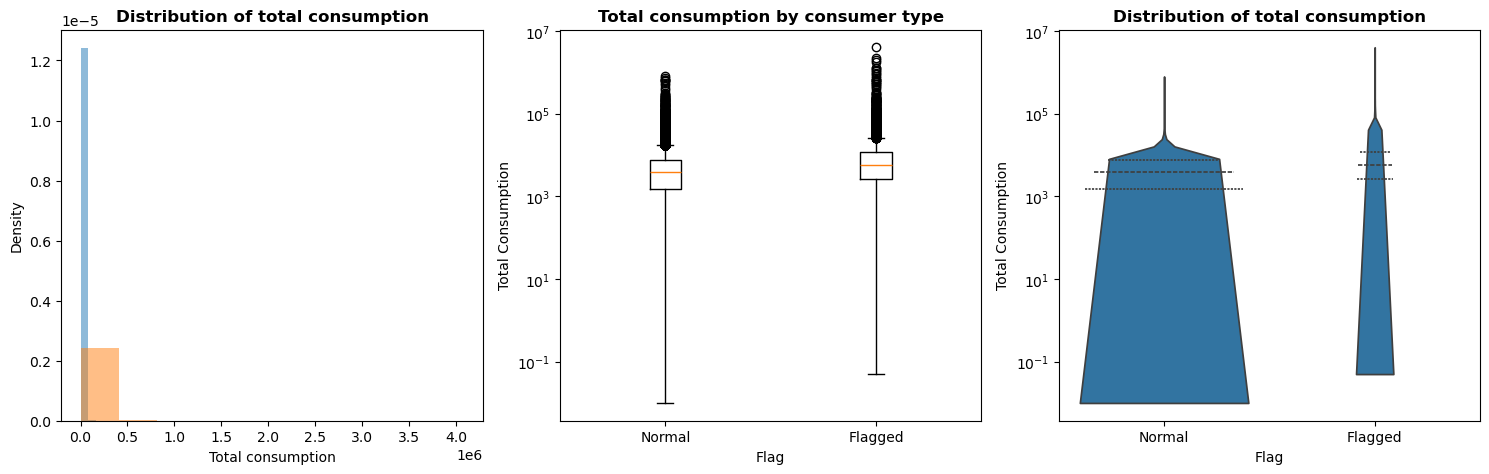

In [13]:
# histogram
fig,ax=plt.subplots(1,3,figsize=(15,5))
# normal
ax[0].hist(
consumer_feature.loc[consumer_feature['FLAG']==0,'total_cons'],
bins=10,alpha=0.5,density=True,label='Normal'
)
# Flagged
ax[0].hist(
consumer_feature.loc[consumer_feature['FLAG']==1,'total_cons'],
bins=10,alpha=0.5,density=True,label='Normal'
)
ax[0].set_xlabel('Total consumption')
ax[0].set_ylabel('Density')
ax[0].set_title('Distribution of total consumption',fontweight='bold')

# Boxplot
 
ax[1].boxplot([
plot_data.loc[plot_data['FLAG']==0,'total_cons'],
plot_data.loc[plot_data['FLAG']==1,'total_cons']],
tick_labels=['Normal','Flagged']
)
ax[1].set_yscale('log')
ax[1].set_ylabel('Total Consumption')
ax[1].set_xlabel("Flag")
ax[1].set_title('Total consumption by consumer type',fontweight='bold')

# Violin grpah

sns.violinplot(
data=plot_data,x='FLAG',y='total_cons',
inner='quartile',ax=ax[2],cut=0
)
ax[2].set_yscale("log")
ax[2].set_xticklabels(['Normal','Flagged'])
ax[2].set_xlabel("Flag")
ax[2].set_ylabel("Total Consumption")
ax[2].set_title('Distribution of total consumption',fontweight='bold')

plt.tight_layout()
plt.show()


#### Obeservation and bussiness interpretation
##### 1. most consumer have low to moderate total consumptio
##### 2. median total consumption of flagged consumer is higher than normal consumer
##### 3. flagged consumer show wider spread (IQR)
##### 4. both group have high consumption outliers



### Business Question 5
#### Do flagged consumers experience larger maximum consumption spikes?

In [14]:
consumer_feature.groupby('FLAG')['max_cons'].describe()

,count,mean,std,min,25%,50%,75%,max
FLAG,,,,,,,,
0,38755.0,137.410047,6809.339023,0.0,10.340,22.03,35.65,800003.32
1,3612.0,427.927510,11722.617595,0.0,22.255,38.05,66.11,514991.78


TypeError: Axis.set_ticks() missing 1 required positional argument: 'ticks'

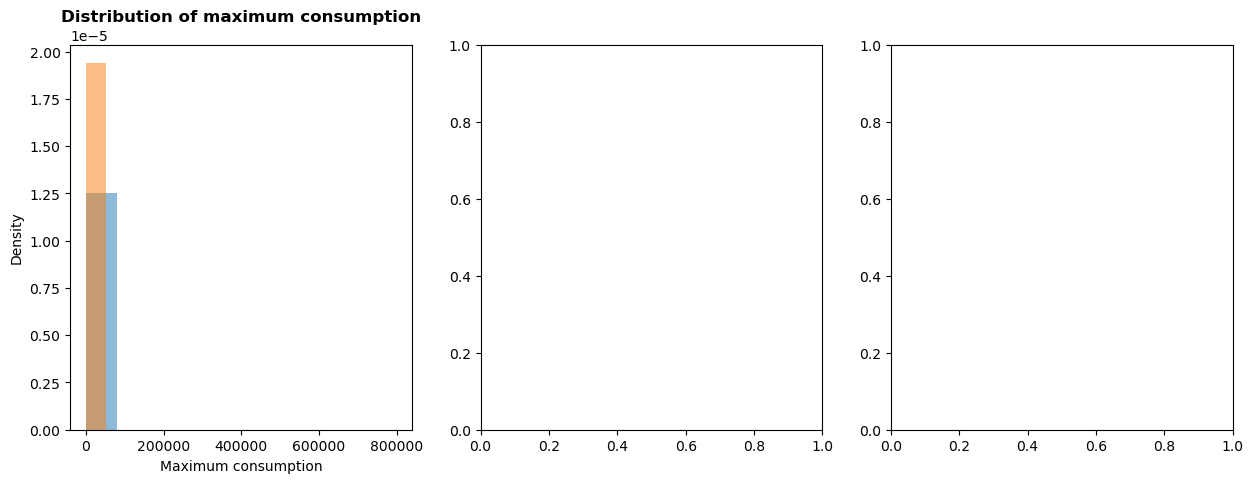

In [15]:
# histogram
fig,ax=plt.subplots(1,3,figsize=(15,5))
# normal
ax[0].hist(
consumer_feature.loc[consumer_feature['FLAG']==0,'max_cons'],
bins=10,alpha=0.5,density=True,label='Normal'
)
# Flagged
ax[0].hist(
consumer_feature.loc[consumer_feature['FLAG']==1,'max_cons'],
bins=10,alpha=0.5,density=True,label='Normal'
)
ax[0].set_xlabel('Maximum consumption')
ax[0].set_ylabel('Density')
ax[0].set_title('Distribution of maximum consumption',fontweight='bold')
ax[0].set_xticks(rotation=45,ha='right')

# Boxplot
 
ax[1].boxplot([
plot_data.loc[plot_data['FLAG']==0,'max_cons'],
plot_data.loc[plot_data['FLAG']==1,'max_cons']],
tick_labels=['Normal','Flagged']
)
ax[1].set_ylabel('Maximum Consumption')
ax[1].set_xlabel("Flag")
ax[1].set_title('Maximum consumption by consumer type',fontweight='bold')

# Violin grpah

sns.violinplot(
data=plot_data,x='FLAG',y='max_cons',
inner='quartile',ax=ax[2],cut=0
)
ax[2].set_yscale("log")
#ax[2].set_xticklabels(['Normal','Flagged'])
ax[2].set_xlabel("Flag")
ax[2].set_ylabel("Maximum Consumption")
ax[2].set_title('Distribution of Maximum consumption',fontweight='bold')

plt.tight_layout()
plt.show()


#### Observation and business interpretation
##### 1. Most consumers have low maximum consumption
##### 2. flagged consumers generally have a higher maximum consumption than normal consumer
##### 3. Flagged consumers display a wider spread
##### 4. both consumers contain exceptionally high peak consummption value

### Business Question 6
#### Do normal consumers experience minimum consumption?

In [ ]:
consumer_feature.groupby('FLAG')['min_cons'].describe()

,count,mean,std,min,25%,50%,75%,max
FLAG,,,,,,,,
0,38755.0,0.913443,5.342357,0.0,0.0,0.0,0.62,479.5
1,3612.0,2.964042,55.215892,0.0,0.0,0.0,1.07,3234.0


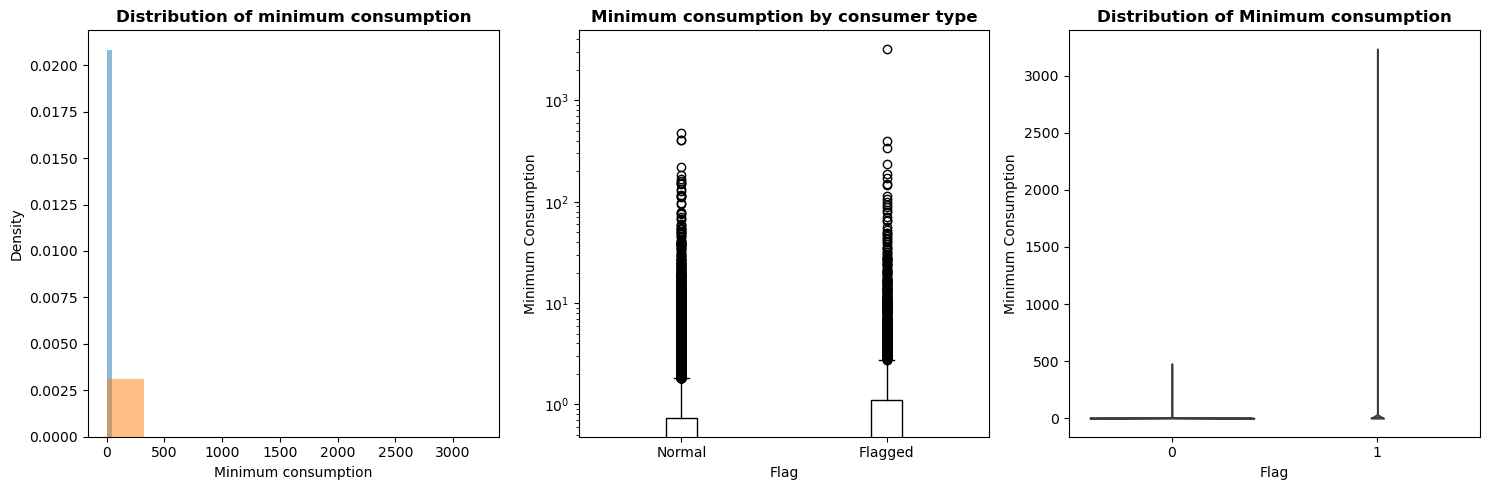

In [ ]:
# histogram
fig,ax=plt.subplots(1,3,figsize=(15,5))
# normal
ax[0].hist(
consumer_feature.loc[consumer_feature['FLAG']==0,'min_cons'],
bins=10,alpha=0.5,density=True,label='Normal'
)
# Flagged
ax[0].hist(
consumer_feature.loc[consumer_feature['FLAG']==1,'min_cons'],
bins=10,alpha=0.5,density=True,label='Normal'
)
ax[0].set_xlabel('Minimum consumption')
ax[0].set_ylabel('Density')
ax[0].set_title('Distribution of minimum consumption',fontweight='bold')

# Boxplot
 
ax[1].boxplot([
plot_data.loc[plot_data['FLAG']==0,'min_cons'],
plot_data.loc[plot_data['FLAG']==1,'min_cons']],
tick_labels=['Normal','Flagged']
)
ax[1].set_yscale('log')
ax[1].set_ylabel('Minimum Consumption')
ax[1].set_xlabel("Flag")
ax[1].set_title('Minimum consumption by consumer type',fontweight='bold')

# Violin grpah

sns.violinplot(
data=plot_data,x='FLAG',y='min_cons',
inner='quartile',ax=ax[2],cut=0
)
#ax[2].set_yscale("log")
#ax[2].set_xticklabels(['Normal','Flagged'])
ax[2].set_xlabel("Flag")
ax[2].set_ylabel("Minimum Consumption")
ax[2].set_title('Distribution of Minimum consumption',fontweight='bold')

plt.tight_layout()
plt.show()


#### Observation and key findings
##### Minimum consumption is highly right-skewed, with most consumers having very low minimum usage.
##### Flagged consumers have a slightly higher median minimum consumption than Normal consumers.
##### Flagged consumers exhibit greater variability and contain more extreme outliers.
##### There is substantial overlap between the two groups, indicating that minimum consumption alone cannot distinguish suspicious consumers

### Business Question 7
#### Are missing readings associated with flagged consumers?

In [ ]:
consumer_feature.groupby("FLAG")["missing_days"].describe()

,count,mean,std,min,25%,50%,75%,max
FLAG,,,,,,,,
0,38757.0,259.495188,296.992529,1.0,13.0,96.0,599.0,1034.0
1,3615.0,325.386722,302.815414,1.0,23.0,221.0,730.0,1034.0


In [16]:
from statsmodels.distributions.empirical_distribution import ECDF
normal=consumer_feature.loc[consumer_feature['FLAG']==0,'missing_days']
flagged=consumer_feature.loc[consumer_feature['FLAG']==1,'missing_days']
ecdf_normal=ECDF(normal)
ecdf_flagged=ECDF(flagged)

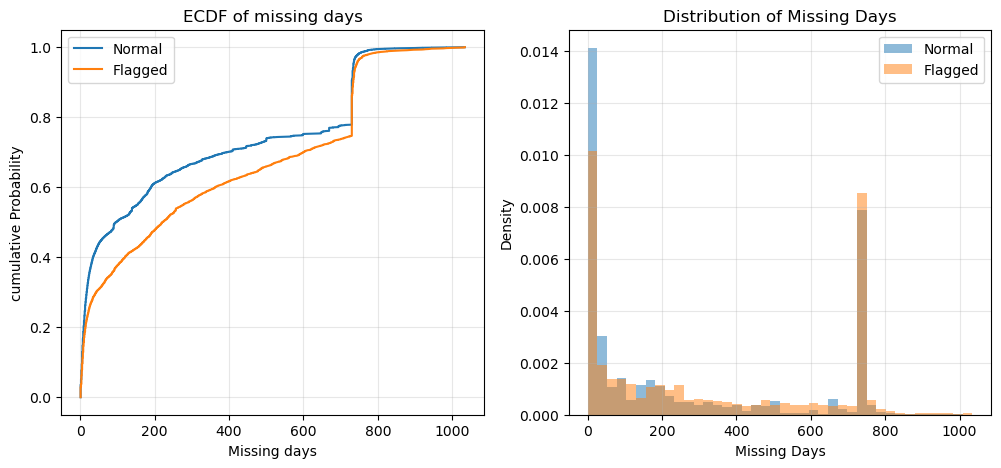

In [ ]:
# ECDF Graph
fig,ax=plt.subplots(1,2,figsize=(12,5))
ax[0].plot(ecdf_normal.x,ecdf_normal.y,label='Normal')
ax[0].plot(ecdf_flagged.x,ecdf_flagged.y,label='Flagged')
ax[0].set_xlabel('Missing days')
ax[0].set_ylabel('cumulative Probability')
ax[0].set_title('ECDF of missing days')
ax[0].legend()
ax[0].grid(alpha=0.3)
# histogram
ax[1].hist(normal,bins=40,density=True,alpha=0.5,label="Normal")
ax[1].hist(flagged,bins=40,density=True,alpha=0.5,label="Flagged")
ax[1].set_xlabel("Missing Days")
ax[1].set_ylabel("Density")
ax[1].set_title("Distribution of Missing Days")
ax[1].legend()
plt.grid(alpha=.3)
plt.show()

c:\Users\vinee\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 21.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\vinee\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 36.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


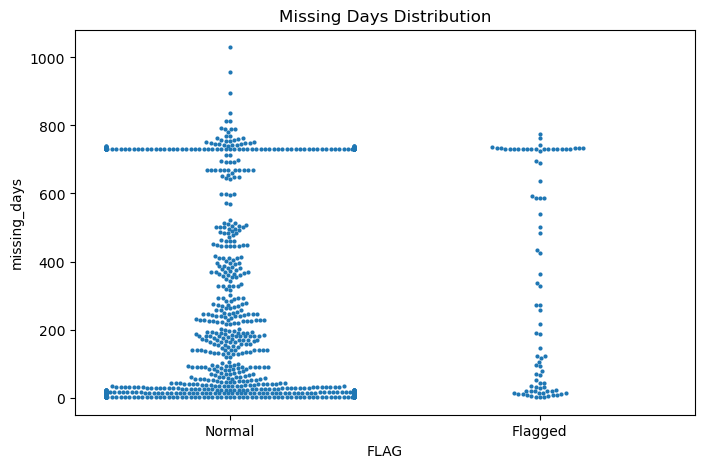

In [ ]:
plt.figure(figsize=(8,5))
sns.swarmplot(
data=consumer_feature.sample(1000, random_state=42),
x="FLAG",y="missing_days",size=3)
plt.xticks([0,1],["Normal","Flagged"])
plt.title("Missing Days Distribution")
plt.show()

#### Observation and Business Interpretation
##### graph1.Cumulative empirical distribution function and Density histogram
##### 1. extreme right skewness with concentration near 0 miss days 
##### 2. Secondary peak around 730 days and long tail up to 1000+ days
##### 3. Flagged consumer accumulate higher counts of missing days
##### graph2. Swarm plot 
##### 1. both class show extreme clustering near 0 and 730 days 
##### 2. normal consumer show dense vertical spread connecting 0 to 730
##### 3, flagged consumer show sparse ocurrence between 100 and 600
#### Key Findings 
##### Flagged meter accumulate more missings days 

### Business Question 8
#### How are consumer behaviour features related to each other ?


In [58]:
corr_features=consumer_feature[[
'mean_cons','median_cons','std_cons','total_cons',
'max_cons','zero_days','missing_days','min_cons'
]]

corr_target=consumer_feature[[
'FLAG','mean_cons','median_cons','std_cons',
'total_cons','max_cons','zero_days','missing_days'
]].corr()

corr_target['FLAG'].sort_values(ascending=False)

target_corr=(coor_target['FLAG'].drop('FLAG').sort_values())

In [59]:
co_matrix=eda_features.corr()


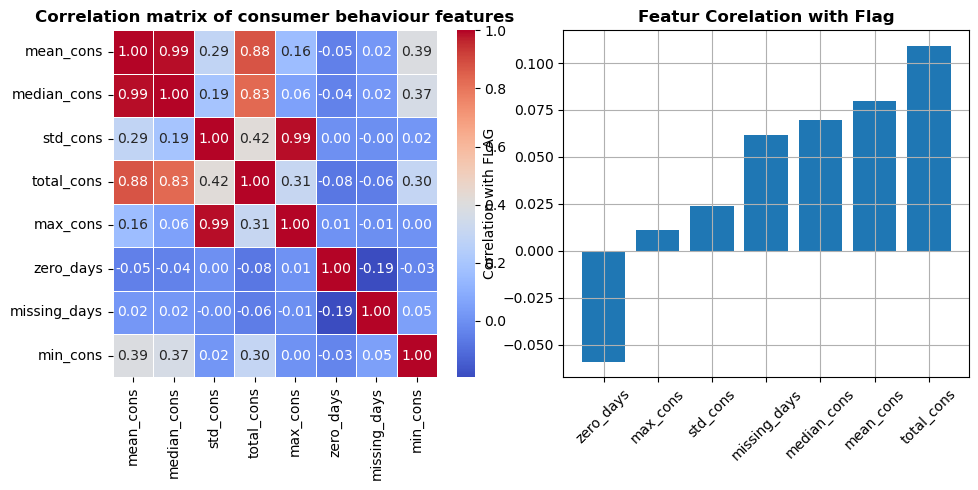

In [72]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
# heatmap for feature correlation
sns.heatmap(co_matrix,annot=True,cmap='coolwarm',linewidths=.5,fmt='.2f',ax=ax[0])
ax[0].set_title("Correlation matrix of consumer behaviour features",fontweight='bold')
plt.tight_layout()
# bar graph for Target correlation
ax[1].bar(target_corr.index,target_corr.values)
ax[1].set_title("Correlation matrix of consumer behaviour features",fontweight='bold')
ax[1].set_ylabel('Correlation with FLAG')
ax[1].set_title('Featur Corelation with Flag',fontweight='bold')
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].grid()
plt.show()

Text(0.5, 1.0, 'Clustered Heatmap of consumer behaviour features')

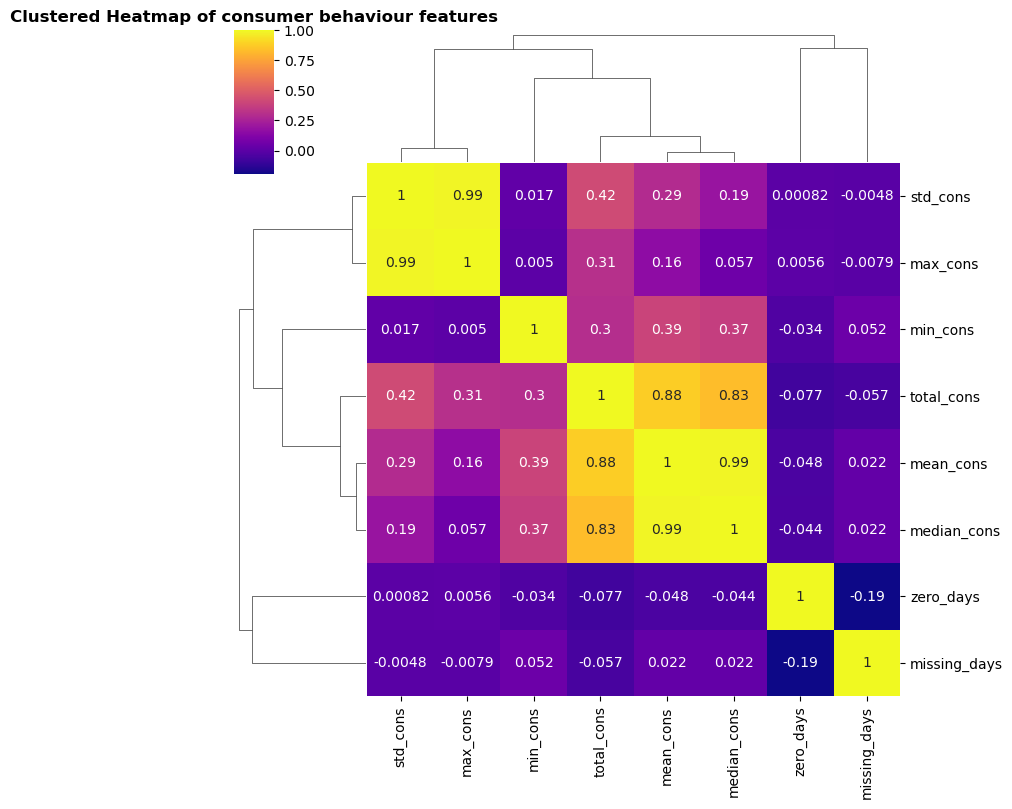

In [61]:
sns.clustermap(co_matrix,annot=True,cmap='plasma',figsize=(8,8))
plt.title("Clustered Heatmap of consumer behaviour features",fontweight='bold')

#### Observation and Business insights
##### graph1. Pearson correlation and target correlation bar chart
##### 1. mean_cons and median_cons have correaltion of 0.99. std_cons and max_cons also have a correlation of 0.99
##### 2. total_cons is highly correlated with mean_cons and median_cons about 0.83
##### 3. total_cons,mean_cons,median_cons,missing_days and std_cons both are highly correalted with target
##### graoh2. Clustered Heatmap
##### 1. cluster1. std_cons and max_cons join at top brach(r=0.99)
##### 2. cluster2. total_cons, mean_cons and median_cons form a tight cluster (r>0.83)


# Exploratory Data Analysis Summary

## Key finidings

#### 1. Consumption Distribution 
##### Electricity consumption is highly right-skewed with several extreme consumption spikes. This is significanly influence average based statistics
#### 2. Mean vs Median
##### Median consumption provide robust representation of consumer behaviour than mean because mean is highly affected by outlier and extreme values 
#### 3. ZEro consumption behaviour 
##### Flagged consumers exhibit difference in zero consumption patterns
#### 4. Consumptionn Variability 
##### Standard deviation effectively captures irregular consumption behaviour and appears to be strong behavioural indicator than average consumption alone.
#### 5. Total consumption 
##### it shows considerable overlap between consumer groups.
#### 6. Maximum Consumption 
##### Extreme consumption spike occur only in a small number of consumers, it represents abnormal behaviour and preserved rather than removed during analysis.
#### 7. Feature Relationships 
##### correlation analysis reveals that some statisical features contain overlapping features, while others contribute, while other shows unique behavioural characteristics 

# Overall Conclusion

#### The exploratory analysis demonstrates that electricity theft cannot be explained by a single consumption statistic. Instead, suspicious behaviour is better represented through a combination of statistical and behavioural characteristics such as variability, zero-consumption days, missing readings and consumption spikes.

#### The insights obtained from this notebook provide a strong foundation for advanced feature engineering and machine learning.
